
# **Actividad 1: Predicción de Temperatura con Series Temporales**


En esta actividad vamos carga datos meteorológicos de la ciudad de Valencia, realizar transformaciones en series temporales y entrenar un modelo LSTM para predicción.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.animation as animation

## **Cargar el Dataset**
Cargamos los datos desde un archivo CSV y verificamos sus primeras filas.

In [12]:
# Cargar el dataset
file_path = 'rvvcca_d_horarios_2021-2022.xlsx'
df = pd.read_excel(file_path)
df.head()
df.shape


(201480, 30)

## **Aplicar transformaciones seno y coseno**



Convertimos la columna de tiempo a un formato adecuado y generamos las transformaciones seno y coseno para manejar la periodicidad del tiempo.

/tmp/ipykernel_669/2487142093.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['Par_Seno_Coseno'] = df[['Hora_sin', 'Hora_cos']].apply(lambda x: f'({x[0]:.2f}, {x[1]:.2f})', axis=1)


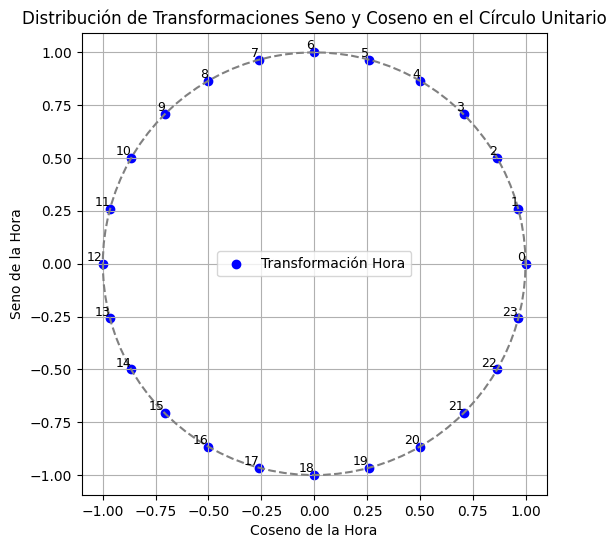

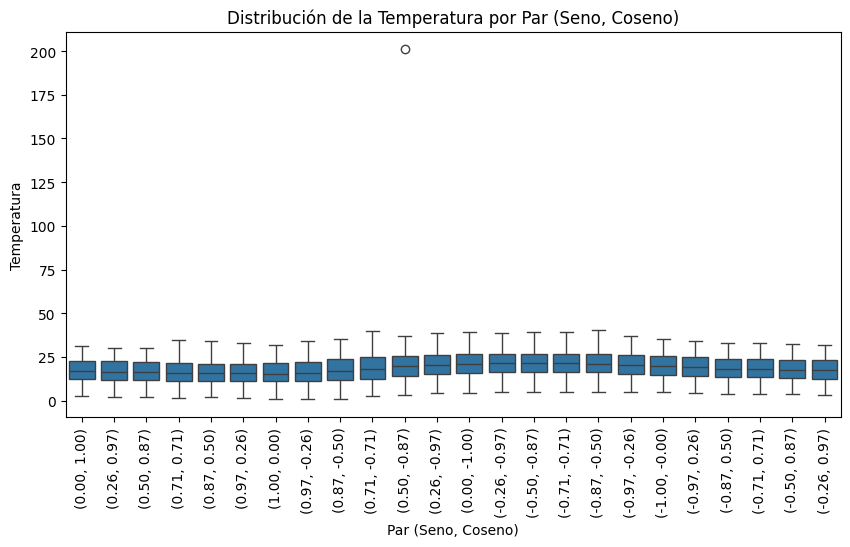

In [13]:
# Convertir la columna 'Fecha' a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Extraer la hora del día y aplicar transformaciones seno y coseno
df['Hora'] = pd.to_datetime(df['Hora'], format='%H:%M:%S', errors='coerce').dt.hour
df['Hora_sin'] = np.sin(2 * np.pi * df['Hora'] / 24)
df['Hora_cos'] = np.cos(2 * np.pi * df['Hora'] / 24)

# Eliminar filas con valores nulos
df = df.dropna(subset=['Hora_sin', 'Hora_cos'])

# Crear una nueva columna combinada con (seno, coseno) como string para mejor visualización
df['Par_Seno_Coseno'] = df[['Hora_sin', 'Hora_cos']].apply(lambda x: f'({x[0]:.2f}, {x[1]:.2f})', axis=1)

# Ordenar por hora
df = df.sort_values(by='Hora')

# Filtrar valores atípicos en la temperatura usando el rango intercuartil
#q1 = df['Temperatura'].quantile(0.25)
#q3 = df['Temperatura'].quantile(0.75)
#iqr = q3 - q1
#limite_inferior = q1 - 1.5 * iqr
#limite_superior = q3 + 1.5 * iqr
#df = df[(df['Temperatura'] >= limite_inferior) & (df['Temperatura'] <= limite_superior)]


#############################

# Generar datos de ejemplo para las horas
horas = np.arange(0, 24, 1)
hora_sin = np.sin(2 * np.pi * horas / 24)
hora_cos = np.cos(2 * np.pi * horas / 24)

# Crear el gráfico
plt.figure(figsize=(6, 6))

# Dibujar el círculo unitario
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='dashed', color='gray')

# Graficar los puntos de transformación seno y coseno
plt.scatter(hora_cos, hora_sin, color='blue', label='Transformación Hora')

# Añadir etiquetas de la hora en cada punto
for i in range(len(horas)):
    plt.text(hora_cos[i], hora_sin[i], str(horas[i]), fontsize=9, ha='right', va='bottom')

# Configuración del gráfico
plt.xlabel("Coseno de la Hora")
plt.ylabel("Seno de la Hora")
plt.title("Distribución de Transformaciones Seno y Coseno en el Círculo Unitario")
plt.legend()
plt.axis("equal")
plt.grid()

# Mostrar el gráfico
plt.show()

###########



# Visualización de la distribución de la temperatura por el par seno-coseno
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Par_Seno_Coseno'], y=df['Temperatura'])
plt.xticks(rotation=90)
plt.xlabel("Par (Seno, Coseno)")
plt.ylabel("Temperatura")
plt.title("Distribución de la Temperatura por Par (Seno, Coseno)")
plt.show()

## **Selección estación específica**


In [14]:
# Filtrar datos para una estación específica
estacion_objetivo = 'Pista Silla'
print(df.shape[0])
df = df.loc[df['Estacion'] == estacion_objetivo].copy()
print(df.shape[0])



201480
17520


## **Extracción de características y gestión de valores nulos**


In [15]:
# Selección de columnas relevantes
features = ['Humedad relativa', 'Presion', 'Radiacion', 'Precipitacion', 'Velocidad del viento', 'Velocidad maxima del viento', 'Hora_sin', 'Hora_cos']
target = 'Temperatura'

# Eliminar filas con valores nulos
df = df.dropna(subset=features + [target])

## **Crear secuencias de datos y definir ventana de tiempo**


Creamos secuencias de datos para que el modelo pueda aprender patrones temporales. Se define una ventana de 10 pasos de tiempo

[t-10, t-9, ..., t-1] → t

In [16]:
# Escalar datos
scaler = MinMaxScaler()
df.loc[:, features + [target]] = scaler.fit_transform(df[features + [target]])

# Función para crear secuencias de datos
def crear_secuencias(datos, pasos):
    X, y = [], []
    for i in range(len(datos) - pasos):
        X.append(datos[i:i+pasos])
        y.append(datos[i+pasos])
    return np.array(X), np.array(y)

# Definir la ventana de tiempo
ventana = 10

## **Visualización**

*  La serie azul representa la serie temporal completa normalizada.
*  La línea roja representa la ventana de tiempo actual.
*  El punto verde representa el valor predicho

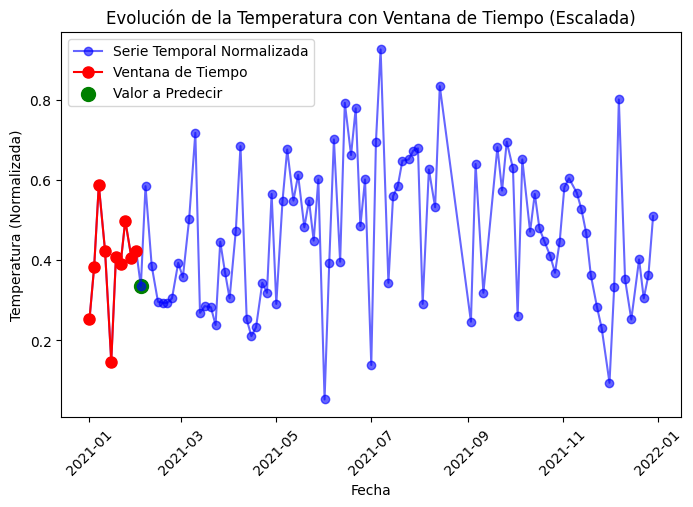

In [17]:
# Asegurar que los datos están ordenados correctamente antes del muestreo
df = df.sort_values(by="Fecha")

datos_serie = df[target].values  # Asegurar que datos_serie esté bien definido
X_seq, y_seq = crear_secuencias(datos_serie, ventana)

# Ajustar el muestreo para mantener una serie lógica
num_muestras = 100  # Reducir el número de muestras visibles para evitar desorden
step = max(1, len(y_seq) // num_muestras)

X_seq_sampled = X_seq[::step]
y_seq_sampled = y_seq[::step]
dias_sampled = df["Fecha"].values[:len(y_seq)][::step]

# Verificar coherencia de tamaños
assert len(dias_sampled) == len(y_seq_sampled), "Error: Longitudes no coinciden."

# Crear la animación con datos ordenados
fig, ax = plt.subplots(figsize=(8, 5))

def update(frame):
    ax.clear()

    # Ploteo de la serie temporal normalizada en azul
    ax.plot(dias_sampled, y_seq_sampled, marker="o", linestyle="-", color="blue", alpha=0.6, label="Serie Temporal Normalizada")

    # Dibujar la ventana de tiempo en rojo
    if frame + ventana < len(dias_sampled):
        x_seq = dias_sampled[frame:frame + ventana]
        y_seq_plot = y_seq_sampled[frame:frame + ventana]
        ax.plot(x_seq, y_seq_plot, "ro-", markersize=8, label="Ventana de Tiempo")


        # Marcar el valor a predecir en verde
        if frame + ventana < len(dias_sampled):
            ax.scatter(dias_sampled[frame + ventana], y_seq_sampled[frame + ventana], color="green", s=100, label="Valor a Predecir")

    ax.set_xlabel("Fecha")
    ax.set_ylabel("Temperatura (Normalizada)")
    ax.set_title("Evolución de la Temperatura con Ventana de Tiempo (Escalada)")
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

# Generar la animación con datos ordenados
ani = animation.FuncAnimation(fig, update, frames=range(len(dias_sampled) - ventana), interval=500, repeat=True)

# Mostrar la animación en HTML
#to_jshtml = ani.to_jshtml()
#from IPython.display import HTML
#HTML(to_jshtml)



## **Modelo de predicción**

*   Definimos una arquitectura simple de LSTM con dropout para evitar sobreajuste. Se usa MSE como función de pérdida.

*   Entrenamos el modelo con Early Stopping para evitar el sobreajuste si la pérdida en validación no mejora después de 5 época.
*  Separamos los datos en entrenamiento (80%) y prueba (20%).
*  La LSTM aprende a predecir valores futuros observando patrones en ventanas de tiempo.


In [18]:
X, y = crear_secuencias(df[target].values, ventana)
X = X.reshape(X.shape[0], X.shape[1], 1)


# División en conjunto de entrenamiento y prueba
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# Construcción del modelo LSTM
model = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(ventana, 1)),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


# Entrenamiento del modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, callbacks=[early_stop])


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


194/194 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0221 - val_loss: 0.0085
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0112 - val_loss: 0.0083
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0103 - val_loss: 0.0084
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0099 - val_loss: 0.0082
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0096 - val_loss: 0.0080
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0093 - val_loss: 0.0081
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0091 - val_loss: 0.0079
Epoch 8/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0088 - val_loss: 0.0078
Epoch 9/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0087 - val_loss: 0.0079
Epoch 10/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0083 - val_loss: 0.0077
Epoch 11/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 12/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/ste

## **Predicción**

Graficamos los valores reales y predichos para evaluar visualmente la calidad de las predicciones del modelo.

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


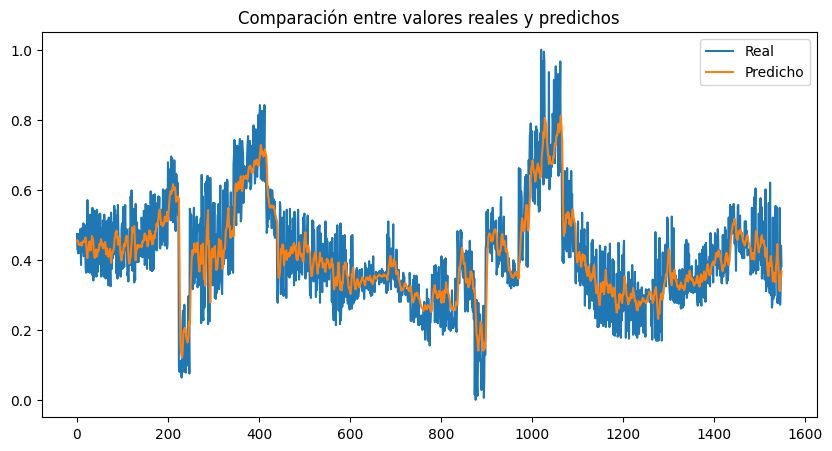

In [19]:
y_pred = model.predict(X_test)

# Visualización de resultados
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Real')
plt.plot(y_pred, label='Predicho')
plt.legend()
plt.title('Comparación entre valores reales y predichos')
plt.show()

## **¿Qué observamos?**


Las predicciones siguen la tendencia general

*   La línea naranja (predicciones) está en el centro de las oscilaciones de la línea azul (valores reales).
*   Esto indica que la LSTM ha aprendido algunos patrones, pero no captura las variaciones abruptas.

El modelo suaviza las predicciones

*   Las predicciones (naranja) son más suaves que los valores reales.
*   Las LSTM tienden a suavizar los datos porque están diseñadas para captar patrones largos, no fluctuaciones extremas.

Diferencias en los picos y valles

*  La línea azul tiene mucho ruido (fluctuaciones rápidas), mientras que la línea naranja no lo sigue con precisión.
*  Puede indicar que el modelo no está capturando correctamente eventos extremos (picos de temperatura).

## **Posibles problemas y soluciones**

Si la predicción está demasiado "suavizada"
*  Posible causa: La LSTM está aprendiendo solo las tendencias generales y no los cambios bruscos.
*  Solución: Aumentar la cantidad de datos de entrada (ventana de tiempo más grande) o agregar más capas LSTM para mejorar la capacidad de modelado.

Si la línea azul es demasiado ruidosa
*  Posible causa: Los datos de entrada tienen mucho ruido (picos abruptos).
*  Solución: Aplicar suavizado con media móvil o reducción de ruido antes de entrenar el modelo.



---





# **Actividad 2: Predicción de Lluvia con Series Temporales**

## **Objetivo**
Los alumnos aplicarán los conceptos aprendidos sobre series temporales y redes neuronales recurrentes
para desarrollar un modelo de predicción de lluvia basado en datos meteorológicos.


## **Instrucciones**

### **1. Búsqueda del Dataset**
Encuentra un conjunto de datos meteorológicos como mínino de 100.000 elementos en plataformas como:
- NOAA Climate Data
- Kaggle - Weather Datasets
- OpenWeather Historical Data
- AEMET OpenData (España)

El dataset debe contener información como:
- Fecha y hora
- Temperatura
- Humedad
- Presión atmosférica
- **Precipitación (lluvia en mm)**



### **2. Preprocesamiento de Datos**
- Limpia los datos eliminando valores nulos.
- Convierte la fecha a formato datetime.
- Transformación seno/coseno para la hora del día.



### **3. División de Datos y Normalización**
- Divide los datos en train (80%) y test (20%).
- Escala los datos usando MinMaxScaler.



### **4. Construcción del Modelo de Predicción**
- Utiliza una Red Neuronal Recurrente (LSTM) para predecir la precipitación futura.
- Usa una ventana de tiempo (lookback window) de al menos 10 horas.



### **5. Entrenamiento y Evaluación del Modelo**
- Entrena el modelo con los datos históricos.
- Evalúa su desempeño con métricas como MAE y RMSE.
- Visualiza los resultados comparando valores reales y predichos.



### **6. Análisis y Reflexión**
- ¿Cuán precisa es la predicción?
- ¿Qué variables parecen ser más relevantes?
- ¿Cómo podríamos mejorar el modelo?


